# **Clinical Trial Success Prediction: Production Engine (v36.0)**

This notebook serves as the **Official Production Engine**. It builds the final predictive model used to feed the FastAPI service and the Streamlit application with XGBoost weights, Therapeutic Area-specific thresholds, and explainability artifacts.

### **Key Production Objectives:**
1. **Full-Universe Training (2009–2022)**: Training on the complete historical cohort to maximize signal.
2. **Recency-Weighted Calibration**: Optimizing decision boundaries using temporal weights.
3. **Global Explainability Export**: Generating SHAP values for all ~29,557 records.
4. **Artifact Persistence**: Saving the model, thresholds, and registry for deployment.

#### <REF:ENV_CONFIG>
> #### **1. Production Environment Configuration**

Configures auto-reload magic for the production pipeline and silences non-critical warnings for clean output logs.

In [1]:
# <REF:ENV_CONFIG_CODE>
# --- AUTO-RELOAD MAGIC COMMANDS ---
%load_ext autoreload
%autoreload 2

import warnings
from tqdm.auto import tqdm
tqdm.pandas()

# Silence Warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# <REF:/ENV_CONFIG_CODE>

#### <REF:PATH_RESOLUTION>
> #### **2. Project Path Resolution and Directory Standards**

Implements dynamic root detection to ensure the production engine can correctly locate the `src` modules and `data` directories across any deployment environment.

In [2]:
# <REF:PATH_RESOLUTION_CODE>
import sys
from pathlib import Path

# 1. Define the Project Root
current_dir = Path.cwd()
project_root = current_dir

while not (project_root / 'src').exists():
    if project_root == project_root.parent:
        raise FileNotFoundError("Could not find project root containing 'src'")
    project_root = project_root.parent

# 2. Add Project Root to System Path
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

# 3. Define Key Paths
DATA_PATH = project_root / "data"
MODELS_PATH = project_root / "models"
FRONTEND_DATA_PATH = project_root / "frontend" / "data"

print(f"Project Root: {project_root}")
print(f"Data Path:    {DATA_PATH}")
print(f"Models Path:  {MODELS_PATH}")

# <REF:/PATH_RESOLUTION_CODE>

Project Root: /home/delaunan/code/delaunan/clintrialpredict
Data Path:    /home/delaunan/code/delaunan/clintrialpredict/data
Models Path:  /home/delaunan/code/delaunan/clintrialpredict/models


#### <REF:LIB_INIT>
> #### **3. Library and Production Module Initialization**

Initializes the core analytical stack and the domain-specific `ClinicalTrialLoader` and `preprocessor` required for the production scoring workflow.

In [3]:
# <REF:LIB_INIT_CODE>
import os
import pandas as pd
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv

# Custom Modules
from src.prep.data_loader_clinpred import ClinicalTrialLoader
from src.prep.preprocessing_clinpred import preprocessor
from src.prep.master_registry import FEATURE_REGISTRY, UI_SCHEMA
from src.prep.append_embeddings import append_new_embeddings

load_dotenv()

# <REF:/LIB_INIT_CODE>

FileNotFoundError: Taxonomy JSON not found at models/taxonomy_01.json

#### <REF:PROD_DATA_LOAD>
> #### **4. Production Universe Loading and Filtering**

Loads the full production universe (`data_clinpred.csv`) and partitions the historical cohort for model training while preserving the total universe for scoring inference.

In [ ]:
# <REF:PROD_DATA_LOAD_CODE>
# 1. AUTOMATED NLP SYNC
append_new_embeddings(str(DATA_PATH))

# 2. DATA LOADING
DATA_CLINPRED_PATH = DATA_PATH / "data_clinpred.csv"

if DATA_CLINPRED_PATH.exists():
    df_full = pd.read_csv(DATA_CLINPRED_PATH, low_memory=False)
    print(f">>> Loaded Production Universe | Shape: {df_full.shape}")
else:
    print(">>> data_clinpred.csv not found. Initializing full ingestion...")
    loader = ClinicalTrialLoader(str(DATA_PATH))
    df_full = loader.load_base_data()
    df_full = loader.add_features(df_full)
    loader.check_and_export_nlp(df_full)

# 3. PRODUCTION FILTERING (Train on Historical, but keep all for scoring)
PROD_START_YEAR = int(os.getenv('PROD_START_YEAR', 2009))
PROD_END_YEAR = int(os.getenv('PROD_END_YEAR', 2022))

df_train = df_full[df_full['target'].notna()].copy()
df_train = df_train[df_train['start_year'].between(PROD_START_YEAR, PROD_END_YEAR)].copy()

# Sort by date for temporal consistency
df_train['start_date'] = pd.to_datetime(df_train['start_date'], errors='coerce')
df_train = df_train.sort_values('start_date')

print(f">>> Production Training Set: {len(df_train):,} trials ({PROD_START_YEAR}-{PROD_END_YEAR})")
print(f">>> Total Universe for Scoring: {len(df_full):,} trials")

# <REF:/PROD_DATA_LOAD_CODE>

>>> Loaded Production Universe | Shape: (29556, 2467)
>>> Production Training Set: 24,191 trials (2009-2022)
>>> Total Universe for Scoring: 29,556 trials


#### <REF:PROD_MODEL_TRAIN>
> #### **5. Production Model Training: Champion XGBoost Pipeline**

Fits the champion XGBoost pipeline on the full historical dataset, utilizing calibrated class weights to handle terminal success/failure imbalance.

In [ ]:
# <REF:PROD_MODEL_TRAIN_CODE>
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

print('>>> Preparing Production Training Matrix...')

# Select features using the _ml and embedding prefix patterns
cols_to_keep = [c for c in df_full.columns if c.endswith('_ml') or
                c.startswith(('crit_', 'sci_', 'endp_')) or
                c == 'therapeutic_area']

X_train = df_train[cols_to_keep]
y_train = df_train['target']

# Calculate Imbalance Ratio
n_pos = y_train.sum()
ratio = (len(y_train) - n_pos) / n_pos

# Champion Hyperparameters
xgb = XGBClassifier(
    n_estimators=500, learning_rate=0.02, max_depth=4,
    min_child_weight=15, gamma=4, subsample=0.8,
    colsample_bytree=0.50, reg_alpha=15, reg_lambda=15,
    scale_pos_weight=ratio, tree_method='hist', eval_metric='logloss',
    n_jobs=-1, random_state=42, enable_categorical=False
)

model = Pipeline([('prep', preprocessor()), ('clf', xgb)])

print(f'>>> Fitting Production Pipeline on {X_train.shape[0]:,} trials...')
model.fit(X_train, y_train)
model.named_steps['prep'].verbose_feature_names_out = True

print('    [DONE] Model training complete.')

# <REF:/PROD_MODEL_TRAIN_CODE>

>>> Preparing Production Training Matrix...
>>> Fitting Production Pipeline on 24,191 trials...
    [DONE] Model training complete.


#### <REF:PROD_CALIBRATION>
> #### **6. Recency-Weighted Decision Threshold Calibration**

Optimizes decision boundaries across Therapeutic Areas using a recency-weighted policy, ensuring the engine reflects contemporary clinical risk profiles.

In [ ]:
# <REF:PROD_CALIBRATION_CODE>
from sklearn.metrics import precision_recall_curve
from scipy.special import logit

def find_optimal_threshold(y_true, y_probs, beta=1.1, weights=None):
    p, r, t = precision_recall_curve(y_true, y_probs, sample_weight=weights)
    f = (1 + beta**2) * (p * r) / (beta**2 * p + r + 1e-9)
    return t[np.argmax(f[:-1])] if len(t) > 0 else 0.5

print('>>> Starting Recency-Weighted Calibration...')

y_prob_train = model.predict_proba(X_train)[:, 1]
train_years = df_train['start_year']
y_min, y_max = train_years.min(), train_years.max()
w_floor, w_ceil = 0.1, 1.0
train_weights = w_floor + (w_ceil - w_floor) * (train_years - y_min) / (y_max - y_min)

df_cal = pd.DataFrame({
    'TA': df_train['therapeutic_area'],
    'true': y_train.values,
    'prob': y_prob_train,
    'weight': train_weights
})

global_thresh = find_optimal_threshold(df_cal['true'], df_cal['prob'], weights=df_cal['weight'])
global_logit = float(logit(np.clip(global_thresh, 1e-5, 1-1e-5)))

final_thresholds = {}
final_threshold_logits = {}
min_samples_policy = 500

ta_counts = df_cal['TA'].value_counts()
for ta, count in ta_counts.items():
    df_ta = df_cal[df_cal['TA'] == ta]
    if count < min_samples_policy or df_ta['true'].nunique() <= 1:
        final_thresholds[ta] = global_thresh
        final_threshold_logits[ta] = global_logit
    else:
        t_ta = find_optimal_threshold(df_ta['true'], df_ta['prob'], weights=df_ta['weight'])
        final_thresholds[ta] = t_ta
        final_threshold_logits[ta] = float(logit(np.clip(t_ta, 1e-5, 1-1e-5)))

print(f"🌍 Global Threshold: {global_thresh:.4f} | Calibrated {len(final_thresholds)} TAs.")

# <REF:/PROD_CALIBRATION_CODE>

>>> Starting Recency-Weighted Calibration...
🌍 Global Threshold: 0.5223 | Calibrated 19 TAs.


#### <REF:PROD_EXPLAIN>
> #### **7. Global Explainability Engine: SHAP TreeExplainer**

Decomposes model predictions into constituent feature contributions for all ~30,000 trials to power the application's root-cause analysis views.

In [ ]:
# <REF:PROD_EXPLAIN_CODE>
import shap

print('>>> Initializing SHAP TreeExplainer...')
prep_step = model.named_steps['prep']
X_full_trans = prep_step.transform(df_full[cols_to_keep])
feature_names = prep_step.get_feature_names_out()

explainer = shap.TreeExplainer(model.named_steps['clf'])
print('>>> Calculating SHAP values for ALL trials (this may take a few minutes)...')
shap_values = explainer.shap_values(X_full_trans)

model_base_value = explainer.expected_value
if isinstance(model_base_value, (list, np.ndarray)):
    model_base_value = model_base_value[0]

print(f"    [DONE] Matrix Shape: {shap_values.shape} | Intercept: {model_base_value:.4f}")

# <REF:/PROD_EXPLAIN_CODE>

>>> Initializing SHAP TreeExplainer...
>>> Calculating SHAP values for ALL trials (this may take a few minutes)...
    [DONE] Matrix Shape: (29556, 31) | Intercept: 0.0078


#### <REF:PROD_SCORE>
> #### **8. Clinical Success Scoring Engine: Normalized Strategic View**

Transforms raw model log-odds into success-oriented scores (0-100) and maps them to strategic impact pillars defined in the master registry.

In [ ]:
# <REF:PROD_SCORE_CODE>
# --- SCORING LOGIC ---
print(">>> Executing Success Scoring Engine (Full Universe)...")

GAIN_FACTOR = 25.0

# 1. Reconstruct Taxonomy from Registry
RISK_TAXONOMY = {}
for feat, meta in FEATURE_REGISTRY.items():
    p = meta.get("pillar")
    s = meta.get("subgroup")
    if not p or not s: continue
    if p not in RISK_TAXONOMY: RISK_TAXONOMY[p] = {}
    if s not in RISK_TAXONOMY[p]:
        RISK_TAXONOMY[p][s] = {"features": [], "logic": meta.get("logic", ""),
                               "pos_impact": meta.get("pos_impact", ""), "neg_impact": meta.get("neg_impact", "")}

    prefix = ""
    enc = meta.get("encoding")
    if enc == "ordinal": prefix = "ordinal__"
    elif enc == "target": prefix = "target__"
    elif enc == "numeric":
        if "arms" in feat: prefix = "num_arms__"
        elif "duration" in feat: prefix = "num_duration__"

    prefixed_feat = f"{prefix}{feat}"
    if feat == "therapeutic_area_ml": RISK_TAXONOMY[p][s]["features"].append("CALIBRATION_OFFSET")
    RISK_TAXONOMY[p][s]["features"].append(prefixed_feat)

# 2. Pillar Aggregation
feat_to_pillar = {}
for i, feat in enumerate(feature_names):
    for pillar, topics in RISK_TAXONOMY.items():
        for topic, details in topics.items():
            if any(feat == f for f in details['features']):
                feat_to_pillar[i] = pillar

pillar_shap_sums = pd.DataFrame(0.0, index=df_full.index, columns=RISK_TAXONOMY.keys())
for i in range(shap_values.shape[1]):
    p = feat_to_pillar.get(i)
    if p: pillar_shap_sums[p] += shap_values[:, i]

# 3. Success Score Calculation
row_threshold_logits = df_full['therapeutic_area'].map(final_threshold_logits).fillna(global_logit)
model_pred_logit = model_base_value + np.sum(shap_values, axis=1)
delta_logit = row_threshold_logits - model_pred_logit

df_full['Clinical_Score'] = (50 + (delta_logit * GAIN_FACTOR)).clip(1, 99)
df_full['Zone'] = pd.cut(df_full['Clinical_Score'], [0, 25, 50, 75, 100], labels=['High Risk', 'Watchlist', 'Good', 'Robust'])

# 4. Attach Pillar Impact Values
for pillar in RISK_TAXONOMY.keys():
    offset_contribution = 0.0
    if pillar == "Therapeutic Context":
        offset_contribution = (row_threshold_logits - model_base_value) * GAIN_FACTOR

    df_full[f"pillar_{pillar.replace(' ', '_')}"] = (pillar_shap_sums[pillar] * GAIN_FACTOR * -1) + offset_contribution

print(f">>> Mean Success Score: {df_full['Clinical_Score'].mean():.1f}")

# <REF:/PROD_SCORE_CODE>

>>> Executing Success Scoring Engine (Full Universe)...
>>> Mean Success Score: 53.4


#### <REF:PROD_EXPORT>
> #### **9. Production Artifact Persistence and Deployment Sync**

Saves the finalized model pipeline, threshold metadata, and SHAP artifacts for ingestion by the FastAPI and Streamlit application layers.

In [ ]:
# <REF:PROD_EXPORT_CODE>
print(">>> Saving Production Artifacts...")

# 1. Save Model Pipeline
joblib.dump(model, MODELS_PATH / "model_prod_01.joblib")

# 2. Save Threshold Metadata
threshold_payload = {
    "global_threshold": float(global_thresh),
    "global_threshold_logit": float(global_logit),
    "base_value": float(model_base_value),
    "gain_factor": GAIN_FACTOR,
    "ta_thresholds": {k: float(v) for k, v in final_thresholds.items()},
    "ta_threshold_logits": {k: float(v) for k, v in final_threshold_logits.items()}
}
with open(MODELS_PATH / "thresholds_01.json", 'w') as f:
    json.dump(threshold_payload, f, indent=4)

# 3. Save SHAP Dictionary (NCT_ID -> SHAP Array) for Audit Mode
shap_dict = {nct_id: shap_values[i].astype(np.float32) for i, nct_id in enumerate(df_full['nct_id'])}
joblib.dump(shap_dict, MODELS_PATH / "shap_values_01.joblib")

# 4. Save Risk Taxonomy Snapshot
taxonomy_payload = {
    "FEATURE_REGISTRY": FEATURE_REGISTRY,
    "UI_SCHEMA": UI_SCHEMA
}
with open(MODELS_PATH / "taxonomy_01.json", 'w') as f:
    json.dump(taxonomy_payload, f, indent=4)

# 5. Save Final Search Registry for Frontend
df_full.to_csv(FRONTEND_DATA_PATH / "search_registry.csv", index=False)

print("✅ All artifacts persisted. Production Engine Ready.")
print(f"   - Model:    {MODELS_PATH / 'model_prod_01.joblib'}")
print(f"   - Taxonomy: {MODELS_PATH / 'taxonomy_01.json'}")
print(f"   - Registry: {FRONTEND_DATA_PATH / 'search_registry.csv'}")
# <REF:/PROD_EXPORT_CODE>


>>> Saving Production Artifacts...
✅ All artifacts persisted. Production Engine Ready.
   - Model:    /home/delaunan/code/delaunan/clintrialpredict/models/model_prod_01.joblib
   - Taxonomy: /home/delaunan/code/delaunan/clintrialpredict/models/taxonomy_01.json
   - Registry: /home/delaunan/code/delaunan/clintrialpredict/frontend/data/search_registry.csv


#### <REF:PROD_PERF_AUDIT>
> #### **10. Production Performance Audit: ROI and Ranking Power**

Evaluates the engine's ranking power using ROC-AUC and PR-AUC. The **ROI Capture Curve** visualizes effectiveness at intercepting portfolio failures, ensuring predictive signal translates into strategic oversight.

Production ROC-AUC: 0.7310
Production PR-AUC:  0.3911


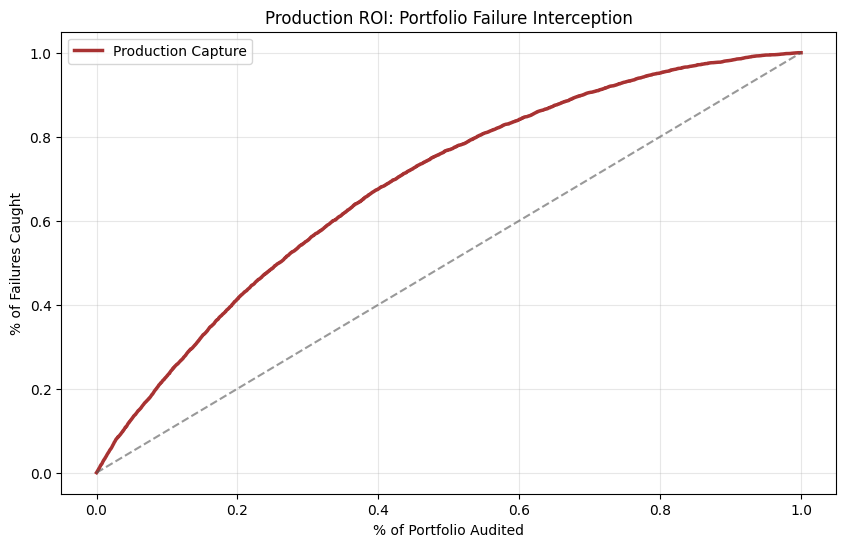

In [ ]:
# <REF:PROD_PERF_AUDIT_CODE>
from sklearn.metrics import roc_auc_score, average_precision_score

auc_val = roc_auc_score(y_train, y_prob_train)
pr_auc_val = average_precision_score(y_train, y_prob_train)

print(f"Production ROC-AUC: {auc_val:.4f}")
print(f"Production PR-AUC:  {pr_auc_val:.4f}")

# ROI Plot (Failure Capture)
data_roi = pd.DataFrame({'target': y_train, 'prob': y_prob_train}).sort_values('prob', ascending=False)
data_roi['cum_pop'] = np.arange(1, len(data_roi) + 1) / len(data_roi)
data_roi['cum_gain'] = data_roi['target'].cumsum() / data_roi['target'].sum()

plt.figure(figsize=(10, 6))
plt.plot(data_roi['cum_pop'], data_roi['cum_gain'], color='#A83232', lw=2.5, label='Production Capture')
plt.plot([0, 1], [0, 1], '--', color='#555555', alpha=0.6)
plt.title("Production ROI: Portfolio Failure Interception")
plt.xlabel("% of Portfolio Audited")
plt.ylabel("% of Failures Caught")
plt.grid(alpha=0.3)
plt.legend()
plt.show()
# <REF:/PROD_PERF_AUDIT_CODE>

#### <REF:CALIBRATION_AUDIT>
> #### **11. Comprehensive Therapeutic Area Calibration Audit**

Validates model stability and strategy efficiency by comparing the **Full Portfolio (2009-2022)** against the **Modern Era (2021-2022)**. This ensures that TA-specific thresholds remain robust under contemporary clinical volatility.

In [ ]:
# <REF:CALIBRATION_AUDIT_CODE>
from sklearn.metrics import precision_score, recall_score, roc_auc_score

print('>>> STEP 11: COMPREHENSIVE THERAPEUTIC AREA ANALYSIS ...')
print('[SCOPE] Full Columns:   2009-2022 Portfolio Baseline')
print('[SCOPE] Recent Columns: 2021-2022 Modern Era Audit (In-Sample)')

def get_ta_stats(df_eval, probs, thresholds_map, g_thresh):
    results = []
    total_y = df_eval['target']
    total_p = (probs >= df_eval['therapeutic_area'].map(thresholds_map).fillna(g_thresh)).astype(int)
    results.append({
        'TA': 'TOTAL (Strategy)',
        'N': len(df_eval),
        'Fail%': f'{total_y.mean():.1%}',
        'AUC': f'{roc_auc_score(total_y, probs):.3f}',
        'Prec': f'{precision_score(total_y, total_p, zero_division=0):.1%}',
        'Rec': f'{recall_score(total_y, total_p, zero_division=0):.1%}',
        'Thresh': f'{g_thresh:.4f}'
    })

    for ta in sorted(df_eval['therapeutic_area'].unique()):
        mask = df_eval['therapeutic_area'] == ta
        y_ta = df_eval.loc[mask, 'target']
        if len(y_ta) == 0 or y_ta.nunique() < 2:
            auc = 'N/A'
        else:
            auc = f'{roc_auc_score(y_ta, probs[mask]):.3f}'

        t_ta = thresholds_map.get(ta, g_thresh)
        p_ta = (probs[mask] >= t_ta).astype(int)

        results.append({
            'TA': ta,
            'N': len(y_ta),
            'Fail%': f'{y_ta.mean():.1%}',
            'AUC': auc,
            'Prec': f'{precision_score(y_ta, p_ta, zero_division=0):.1%}',
            'Rec': f'{recall_score(y_ta, p_ta, zero_division=0):.1%}',
            'Thresh': f'{t_ta:.4f}'
        })
    return pd.DataFrame(results)

y_prob_ser = pd.Series(y_prob_train, index=df_train.index)

mask_full = df_train['start_year'].between(2009, 2022)
mask_rec  = df_train['start_year'] >= 2021

stats_full = get_ta_stats(df_train[mask_full], y_prob_ser[mask_full], final_thresholds, global_thresh)
stats_rec  = get_ta_stats(df_train[mask_rec], y_prob_ser[mask_rec], final_thresholds, global_thresh)

summary = stats_full[['TA', 'N', 'Fail%', 'AUC', 'Prec', 'Rec']].merge(
    stats_rec[['TA', 'N', 'Fail%', 'AUC', 'Prec', 'Rec', 'Thresh']],
    on='TA', suffixes=(' Full', ' Rec')
)

total_row = summary[summary['TA'] == 'TOTAL (Strategy)']
ta_rows = summary[summary['TA'] != 'TOTAL (Strategy)'].copy()
ta_rows['N Full Int'] = ta_rows['N Full'].astype(int)
ta_rows = ta_rows.sort_values('N Full Int', ascending=False).drop(columns=['N Full Int'])
summary_sorted = pd.concat([total_row, ta_rows])

print("\n=== THERAPEUTIC AREA COMPARATIVE STATISTICS (SYNCED) ===")
header = "TA                   | F.N    | F.F%    | F.AUC  | F.Pr   | F.Re   | R.N    | R.F%    | R.AUC  | R.Pr   | R.Re   | Thresh"
print(header)
print("-" * len(header))
for _, row in summary_sorted.iterrows():
    line = f"{row['TA']:<20} | {row['N Full']:<6} | {row['Fail% Full']:<7} | {row['AUC Full']:<6} | {row['Prec Full']:<6} | {row['Rec Full']:<6} | {row['N Rec']:<6} | {row['Fail% Rec']:<7} | {row['AUC Rec']:<6} | {row['Prec Rec']:<6} | {row['Rec Rec']:<6} | {row['Thresh']}"
    print(line)
# <REF:/CALIBRATION_AUDIT_CODE>

>>> STEP 11: COMPREHENSIVE THERAPEUTIC AREA ANALYSIS ...
[SCOPE] Full Columns:   2009-2022 Portfolio Baseline
[SCOPE] Recent Columns: 2021-2022 Modern Era Audit (In-Sample)

=== THERAPEUTIC AREA COMPARATIVE STATISTICS (SYNCED) ===
TA                   | F.N    | F.F%    | F.AUC  | F.Pr   | F.Re   | R.N    | R.F%    | R.AUC  | R.Pr   | R.Re   | Thresh
-------------------------------------------------------------------------------------------------------------------------
TOTAL (Strategy)     | 24191  | 20.1%   | 0.731  | 33.4%  | 70.1%  | 2928   | 31.1%   | 0.776  | 48.6%  | 81.0%  | 0.5223
ONCOLOGY             | 4704   | 32.3%   | 0.674  | 40.1%  | 81.0%  | 514    | 58.4%   | 0.659  | 65.5%  | 90.7%  | 0.6017
INFECTIONS           | 2522   | 15.7%   | 0.792  | 33.7%  | 69.6%  | 510    | 27.3%   | 0.768  | 45.8%  | 78.4%  | 0.4405
NEUROLOGY            | 1887   | 23.2%   | 0.668  | 31.4%  | 78.3%  | 242    | 32.2%   | 0.702  | 42.0%  | 84.6%  | 0.5126
DERMATOLOGY          | 1846   | 10.2%

### **Consolidated Production & Deployment Manifest**

| Artifact | Storage Location | Content Description | Consumption Layer |
| :--- | :--- | :--- | :--- |
| **Production Model** | `models/model_prod_01.joblib` | Final Scikit-learn Pipeline (Preprocessor + XGBClassifier) trained on 2009–2022 historical cohort. | **FastAPI** (`api/main.py`) |
| **Threshold Logic** | `models/thresholds_01.json` | Recency-weighted decision boundaries (logits) and calibration constants (Gain Factor, Intercept). | **FastAPI** (`api/main.py`) |
| **SHAP Store** | `models/shap_values_01.joblib` | Pre-calculated feature attributions for all ~30,000 trials, enabling instant "Audit Mode" lookups. | **FastAPI** (`api/main.py`) |
| **Taxonomy Logic** | `models/taxonomy_01.json` | Logic-locked snapshot of Feature Registry and UI Schema to ensure API/UI alignment. | **FastAPI** (`api/main.py`) |
| **Search Registry** | `frontend/data/search_registry.csv` | Full trial universe enriched with success scores, zones, and scientific narratives for the search interface. | **Streamlit** (`frontend/app.py`) |

**Production Engine Summary:**
*   **Engine Maturity:** The model utilizes the full historical signal (2009–2022) with recency weighting to prioritize contemporary R&D success patterns.
*   **Success Orientation:** All raw risk probabilities are transformed into a **0–100 Success Score** where **50.0** is the specific TA decision boundary.
*   **Pillar Attribution:** SHAP values are aggregated into four strategic pillars (**Therapeutic Context**, **Scientific Design**, **Execution Framework**, **Patient Profile**) for root-cause explainability.

**Deployment Architecture Verification:**
- **API Synchronization:** The FastAPI layer in `api/main.py` is configured to load all logic artifacts directly from the root `models/` directory.
- **Frontend Isolation:** The Streamlit app in `frontend/app.py` consumes its data from the local `frontend/data/` path, ensuring the UI remains performant and easy to package for deployment.
- **Backward Compatibility:** While historical files like `app_search_data_01.csv` may exist in `models/`, the production engine now defaults to `search_registry.csv` to align with the finalized UI naming convention.